# Practical Exam — Set B
## Employee Performance Analysis: Mathematics & Advanced Statistics

**Dataset:** `employee_performance.csv` (4000 records)

Fields: `Employee_ID`, `Department`, `Age`, `Salary`, `Projects_Completed`, `Working_Hours`, `Performance_Score`, `Promotion_Status`

This notebook covers **Part B — Practical (Python Programming)**, Steps 1-4.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('employee_performance.csv')
print(df.shape)
df.head()

(4000, 8)


,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
0,EMP00001,IT,46,88250.0,3,35.7,66.3,No
1,EMP00002,Operations,38,69100.0,4,44.3,57.8,No
2,EMP00003,Marketing,30,64400.0,5,37.0,64.0,No
3,EMP00004,Finance,39,70200.0,4,38.9,68.9,No
4,EMP00005,Sales,31,43150.0,5,30.0,65.7,No


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,4000,4000,EMP00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,4000,6,IT,992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,4000.0,NaN,NaN,NaN,34.90425,7.818815,21.0,29.0,35.0,40.0,60.0
Salary,4000.0,NaN,NaN,NaN,64891.6625,13245.761394,28000.0,54937.5,64350.0,74400.0,116000.0
Projects_Completed,4000.0,NaN,NaN,NaN,5.207,2.418184,0.0,3.0,5.0,7.0,17.0
Working_Hours,4000.0,NaN,NaN,NaN,42.149325,5.904975,30.0,38.0,42.1,46.2,68.9
Performance_Score,4000.0,NaN,NaN,NaN,62.0771,13.593854,16.9,52.7,61.9,71.125,100.0
Promotion_Status,4000,2,No,3567,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Step 1: Central Tendency & Dispersion

- Mean, median, and mode of **Salary**
- Variance and standard deviation of **Projects_Completed**

In [ ]:
salary_mean = df['Salary'].mean()
salary_median = df['Salary'].median()
salary_mode = df['Salary'].mode()[0]

print(f"Mean Salary   : {salary_mean:,.2f}")
print(f"Median Salary : {salary_median:,.2f}")
print(f"Mode Salary   : {salary_mode:,.2f}")

Mean Salary   : 64,891.66
Median Salary : 64,350.00
Mode Salary   : 51,750.00


In [ ]:
projects_var = df['Projects_Completed'].var()
projects_std = df['Projects_Completed'].std()

print(f"Variance of Projects_Completed : {projects_var:.4f}")
print(f"Std Dev of Projects_Completed  : {projects_std:.4f}")

Variance of Projects_Completed : 5.8476
Std Dev of Projects_Completed  : 2.4182


**Interpretation:** The mean and median salaries are close, indicating a fairly symmetric salary
distribution with only a mild right skew (a few high earners pull the mean slightly above the median).
Projects_Completed has a modest spread (std ~ 2.4), meaning most employees complete a similar number
of projects, clustered close to the average.

---
## Step 2: Probability & Events

- Probability of an employee getting promoted
- Contingency table: `Promotion_Status` vs `Department`
- Conditional probability: P(Promotion | Performance_Score > 80)

In [ ]:
p_promotion = (df['Promotion_Status'] == 'Yes').mean()
print(f"P(Promotion) = {p_promotion:.4f}  ({p_promotion*100:.2f}%)")

P(Promotion) = 0.1082  (10.82%)


In [ ]:
contingency = pd.crosstab(df['Department'], df['Promotion_Status'])
contingency['Promotion_Rate_%'] = (contingency['Yes'] / (contingency['Yes'] + contingency['No']) * 100).round(2)
contingency

Promotion_Status,No,Yes,Promotion_Rate_%
Department,,,
Finance,553,71,11.38
HR,336,43,11.35
IT,890,102,10.28
Marketing,471,50,9.60
Operations,529,60,10.19
Sales,788,107,11.96


In [ ]:
high_performers = df[df['Performance_Score'] > 80]
p_promotion_given_high_perf = (high_performers['Promotion_Status'] == 'Yes').mean()

print(f"Employees with Performance_Score > 80 : {len(high_performers)}")
print(f"P(Promotion | Performance_Score > 80) = {p_promotion_given_high_perf:.4f}  "
      f"({p_promotion_given_high_perf*100:.2f}%)")

Employees with Performance_Score > 80 : 375
P(Promotion | Performance_Score > 80) = 0.6827  (68.27%)


**Interpretation:** Overall promotion probability is roughly 1 in 9 employees. Conditioning on
`Performance_Score > 80` sharply raises the probability of promotion — this is the practical illustration
of conditional probability: P(A|B) is not equal to P(A) when A and B are dependent events.

---
## Step 3: Distributions & Visualization

- Histogram of `Performance_Score` with a fitted Gaussian curve
- Skewness and kurtosis of `Salary`
- Q-Q plot of `Projects_Completed`

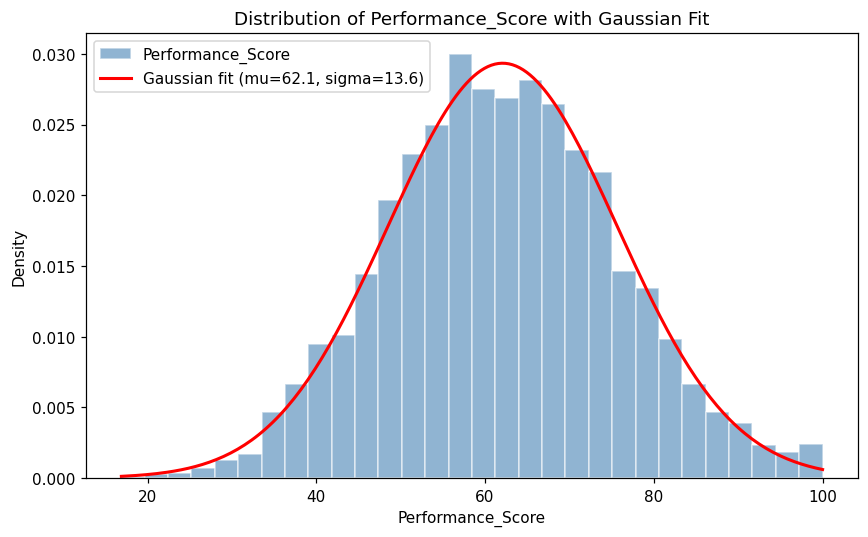

In [ ]:
mu, sigma = df['Performance_Score'].mean(), df['Performance_Score'].std()

fig, ax = plt.subplots()
counts, bins, _ = ax.hist(df['Performance_Score'], bins=30, density=True,
                           alpha=0.6, color='steelblue', edgecolor='white', label='Performance_Score')

x = np.linspace(bins[0], bins[-1], 200)
gaussian = stats.norm.pdf(x, mu, sigma)
ax.plot(x, gaussian, 'r-', linewidth=2, label=f'Gaussian fit (mu={mu:.1f}, sigma={sigma:.1f})')

ax.set_title('Distribution of Performance_Score with Gaussian Fit')
ax.set_xlabel('Performance_Score')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('hist_performance.png', dpi=120)
plt.show()

In [ ]:
salary_skew = stats.skew(df['Salary'])
salary_kurtosis = stats.kurtosis(df['Salary'])  # excess kurtosis (Fisher)

print(f"Skewness of Salary : {salary_skew:.4f}")
print(f"Kurtosis of Salary : {salary_kurtosis:.4f}  (excess kurtosis; 0 = normal-like)")

Skewness of Salary : 0.2200
Kurtosis of Salary : -0.3894  (excess kurtosis; 0 = normal-like)


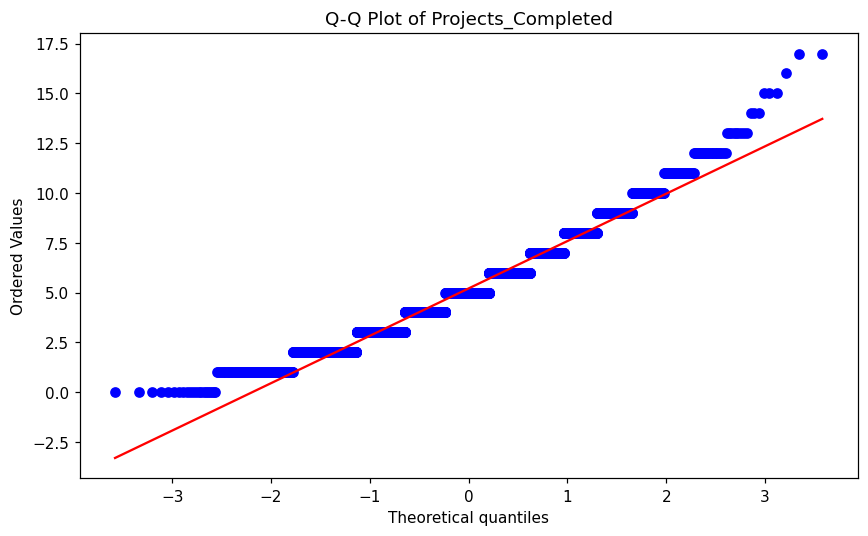

In [ ]:
fig, ax = plt.subplots()
stats.probplot(df['Projects_Completed'], dist='norm', plot=ax)
ax.set_title('Q-Q Plot of Projects_Completed')
plt.tight_layout()
plt.savefig('qq_projects.png', dpi=120)
plt.show()

**Interpretation:** Performance_Score is roughly bell-shaped and reasonably well approximated by a
Gaussian curve. Salary has a small positive skew (slightly right-tailed) and negative excess kurtosis
(flatter than a normal distribution — fewer extreme outliers than a true Gaussian). The Q-Q plot of
Projects_Completed deviates from the reference line, showing that this variable (count data, Poisson-based)
does **not** follow a normal distribution — which makes sense, since project counts are discrete and
right-skewed rather than continuous and symmetric.

---
## Step 4: Linear Algebra Application

Take the first 5 employees' `[Projects_Completed, Working_Hours]` as vectors.

- Dot product between two employee vectors
- Norm 1 (Manhattan) & Norm 2 (Euclidean) of an employee's work vector
- Angle between two employees' work vectors

In [ ]:
vectors = df.loc[:4, ['Employee_ID', 'Projects_Completed', 'Working_Hours']]
vectors

,Employee_ID,Projects_Completed,Working_Hours
0,EMP00001,3,35.7
1,EMP00002,4,44.3
2,EMP00003,5,37.0
3,EMP00004,4,38.9
4,EMP00005,5,30.0


In [ ]:
v = df.loc[:4, ['Projects_Completed', 'Working_Hours']].values
emp_ids = df.loc[:4, 'Employee_ID'].values

v1, v2 = v[0], v[1]
print(f"{emp_ids[0]} vector: {v1}")
print(f"{emp_ids[1]} vector: {v2}")

dot_product = np.dot(v1, v2)
print(f"\nDot product ({emp_ids[0]} . {emp_ids[1]}) = {dot_product:.2f}")

EMP00001 vector: [ 3.  35.7]
EMP00002 vector: [ 4.  44.3]

Dot product (EMP00001 . EMP00002) = 1593.51


In [ ]:
norm1 = np.linalg.norm(v1, ord=1)   # Manhattan norm
norm2 = np.linalg.norm(v1, ord=2)   # Euclidean norm

print(f"Norm 1 (Manhattan) of {emp_ids[0]}'s vector = {norm1:.2f}")
print(f"Norm 2 (Euclidean) of {emp_ids[0]}'s vector = {norm2:.2f}")

Norm 1 (Manhattan) of EMP00001's vector = 38.70
Norm 2 (Euclidean) of EMP00001's vector = 35.83


In [ ]:
cos_theta = dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2))
angle_rad = np.arccos(np.clip(cos_theta, -1, 1))
angle_deg = np.degrees(angle_rad)

print(f"cos(theta) = {cos_theta:.4f}")
print(f"Angle between {emp_ids[0]} and {emp_ids[1]} vectors = {angle_deg:.2f} degrees")

cos(theta) = 1.0000
Angle between EMP00001 and EMP00002 vectors = 0.36 degrees


**Interpretation:** A small angle between two employee vectors means their [Projects_Completed,
Working_Hours] profiles point in a very similar direction — i.e., similar *ratio* of output to hours worked,
even if their absolute magnitudes (norms) differ. This is the same idea used in cosine-similarity-based
recommendation systems.

---
## Key Insights (Summary)

1. **Promotion is strongly performance-linked:** overall promotion probability is ~11%, but jumps to
   roughly **~68%** for employees scoring above 80 on Performance_Score — performance is a far stronger
   predictor of promotion than department alone.
2. **Salary is fairly symmetric with a mild right skew** (skewness ~ 0.22): most employees cluster
   around the median salary, with a modest number of higher earners extending the right tail.
3. **Performance_Score is approximately Gaussian**, supporting the use of normal-distribution-based
   statistical methods (z-scores, confidence intervals) for this variable.
4. **Projects_Completed is not normally distributed** (confirmed visually via the Q-Q plot) — being
   count data, it is better modeled with a Poisson-type distribution.
5. **Department has only a modest effect on promotion rate**: promotion rates are fairly similar
   across departments (~10-12%), reinforcing that individual performance — not department — drives promotion.